# Обработка `infm_params_text`: до и после

Ноутбук показывает работу модуля [`src/infm_params.py`](../src/infm_params.py)
на фильтрах запроса (`search_infm_params_text`) и параметрах объявления
(`item_infm_params_text`).

**Что делает модуль**

* **Блок A — фильтры.** Из текста запроса извлекаются 4 фильтра, из текста
  объявления — соответствующие им поля:

  | Ключ | Запрос | Объявление |
  |---|---|---|
  | Вид услуги | `filter_category` | `item_category` |
  | Тип услуги | `filter_subcategory` | `item_subcategory` |
  | Предмет или специальность | `filter_subject` | `item_subjects` |
  | Онлайн-запись | `filter_online_booking` | `item_online_booking` |

  «Кто оказывает услуги» не используется: «Частный исполнитель» и «Компания»
  по данным объявления не проверить, а «Женщина» / «Мужчина» встречаются лишь
  в одном запросе бенчмарка.

  Вид и тип услуги с обеих сторон кодируются одним правилом:

  | В тексте | Вид услуги | Тип услуги |
  |---|---|---|
  | ключ со значением | значение | значение |
  | ключ без значения | «No category» | «No subcategory» |
  | ключа нет | `None` | `None` |

  `None` у запроса — «фильтра нет», у объявления — «не проходит фильтр по
  этому полю».

* **Блок B — текст для ретрива.** `item_params_text` — содержательная часть
  параметров объявления без шаблона, расписания, адреса и служебных полей.

**План**

1. Данные
2. Как было
3. Разбор на пары «ключ — значение»
4. Блок A: фильтры запроса
5. Блок A: поля объявления
6. Проверка: выполняют ли позитивы фильтры — до и после
7. Блок B: текст для ретрива — до и после
8. Итоги
9. Что дальше: остальные поля параметров

In [0]:
import re
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from matplotlib.ticker import PercentFormatter

ROOT = Path("..").resolve() if Path("../src").exists() else Path(".").resolve()
sys.path.insert(0, str(ROOT / "src"))
import infm_params as ip

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
TRAIN_SAMPLE = 150_000
DATA = ROOT / "dataset"  # сырые файлы: в processed текст параметров уже разобран

# палитра и стиль — как в 01_eda.ipynb
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, SECOND, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 9, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlecolor": INK, "axes.titlepad": 12, "axes.titlelocation": "left",
    "axes.labelcolor": SECOND, "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": SECOND, "ytick.labelcolor": SECOND,
    "grid.color": GRID, "grid.linewidth": 0.8, "legend.frameon": False,
    "legend.fontsize": 8, "lines.linewidth": 2,
})


def grouped_barh(ax, labels, series, names, fmt="{:.1%}"):
    """Горизонтальные сгруппированные бары, по 2 серии, с подписями значений."""
    y = np.arange(len(labels))
    h = 0.38
    for i, (values, name) in enumerate(zip(series, names)):
        pos = y + (i - 0.5) * h
        ax.barh(pos, values, height=h - 0.04, color=SERIES[i], label=name)
        for p, v in zip(pos, values):
            if not np.isnan(v):
                ax.text(v, p, " " + fmt.format(v), va="center", fontsize=7.5, color=SECOND)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.legend(loc="lower right", bbox_to_anchor=(1, 1.0), ncol=2)


def is_value(x):
    return ip._is_value(x)


def real_value(x):
    """Настоящее значение вида/типа услуги: не None и не метка «No category» / «No subcategory»."""
    return ip._is_value(x) and x not in (ip.NO_CATEGORY, ip.NO_SUBCATEGORY)


print("готово")

готово


## 1. Данные

* `benchmark_queries` и `benchmark_items` — целиком;
* `train` — случайная потоковая выборка из 150 тыс. пар (файл весит почти
  500 МБ, целиком в память его не читаем).

Читаем **сырые** файлы из `dataset/`: ноутбук показывает разбор исходного
текста параметров, а `src/preprocess.py` его уже разобрал и удалил из
`dataset/processed/`.

In [1]:
def sample_parquet(path, columns, n, seed=RANDOM_STATE, batch_size=50_000):
    """Потоковая случайная выборка ~n строк."""
    rng = np.random.default_rng(seed)
    pf = pq.ParquetFile(path)
    keep = n / pf.metadata.num_rows
    parts = [b.to_pandas()[lambda d: rng.random(len(d)) < keep]
             for b in pf.iter_batches(batch_size=batch_size, columns=columns)]
    return pd.concat(parts, ignore_index=True)


queries = pq.read_table(DATA / "benchmark_queries.parquet").to_pandas()
items = pq.read_table(DATA / "benchmark_items.parquet",
                      columns=["item_id", "item_microcat_id", "item_category_id",
                               "item_infm_params_text"]).to_pandas()
train = sample_parquet(DATA / "train.parquet",
                       ["search_query", "search_infm_params_text", "item_id",
                        "item_microcat_id", "item_title_raw", "item_description_raw",
                        "item_infm_params_text"], TRAIN_SAMPLE)

print(f"benchmark_queries: {len(queries):,}")
print(f"benchmark_items:   {len(items):,}")
print(f"train (выборка):   {len(train):,}")

benchmark_queries: 2,452
benchmark_items:   189,212
train (выборка):   150,344


## 2. Как было

Оба поля — сплошной текст без разделителей. Фильтр запроса — короткая строка,
параметры объявления — длинная простыня, где ключи, значения, цены, расписание
и адрес идут подряд.

In [2]:
raw_filters = queries.search_infm_params_text.fillna("").str.strip()
train_filters = train.search_infm_params_text.fillna("").str.strip()

pd.DataFrame({
    "": ["строк с непустым фильтром", "уникальных строк фильтра"],
    "бенчмарк": [f"{(raw_filters != '').mean():.1%}", f"{raw_filters[raw_filters != ''].nunique():,}"],
    "train (выборка)": [f"{(train_filters != '').mean():.1%}",
                        f"{train_filters[train_filters != ''].nunique():,}"],
})

,,бенчмарк,train (выборка)
0,строк с непустым фильтром,36.9%,67.0%
1,уникальных строк фильтра,131,"1,667"


In [3]:
print("Самые частые фильтры в бенчмарке:")
raw_filters[raw_filters != ""].value_counts().head(10).to_frame("запросов")

Самые частые фильтры в бенчмарке:


,запросов
search_infm_params_text,
Вид услуги,60
"Вид услуги Оборудование, производство",53
Вид услуги Ремонт и отделка,48
"Вид услуги Праздники, мероприятия",40
"Вид услуги Обучение, курсы",39
"Вид услуги Красота, здоровье",36
Вид услуги Вывоз мусора и вторсырья,36
Вид услуги Грузоперевозки,31
"Тип услуги Услуги парикмахера Вид услуги Красота, здоровье",26


In [4]:
EXAMPLE_FILTERS = [
    "Рейтинг пользователя 4 звезды и выше",
    "Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье",
]
# объявление из примера, разобранного при обсуждении
EXAMPLE_ITEM = (
    "Вид услуги Красота, здоровье Место оказания услуг Санкт-Петербург, садоводческое "
    "некоммерческое товарищество Веретено-2, Цветочная ул., 146 Тип услуги СПА-услуги, "
    "массаж Тип стоимости за час Где вы оказываете услуги У себя дома Ваши клиенты Женщины "
    "Ваши клиенты Мужчины Кто оказывает услуги Женщина Кто оказывает услуги Мужчина "
    "Специальность или сфера Спа-процедуры Начальная цена Тип стоимости за час Услуга "
    "Аренда бани Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час "
    "Услуга Баня Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час "
    "Услуга Спа-процедуры для тела Стоимость 1600 Продолжительность 1 ч Онлайн-запись "
    "Провайдер Календарей бронирования avito Признак предзаполнения прайс листа 2 Опыт "
    "работы Больше 10 лет Куда выезжаете Не выезжаю"
)

words = items.item_infm_params_text.str.split().str.len()
print(f"Параметры объявления: медиана {words.median():.0f} слов, "
      f"p90 {words.quantile(0.9):.0f}, максимум {words.max():,}\n")
print("Пример item_infm_params_text:\n")
print(EXAMPLE_ITEM)

Параметры объявления: медиана 110 слов, p90 272, максимум 2,468

Пример item_infm_params_text:

Вид услуги Красота, здоровье Место оказания услуг Санкт-Петербург, садоводческое некоммерческое товарищество Веретено-2, Цветочная ул., 146 Тип услуги СПА-услуги, массаж Тип стоимости за час Где вы оказываете услуги У себя дома Ваши клиенты Женщины Ваши клиенты Мужчины Кто оказывает услуги Женщина Кто оказывает услуги Мужчина Специальность или сфера Спа-процедуры Начальная цена Тип стоимости за час Услуга Аренда бани Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час Услуга Баня Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час Услуга Спа-процедуры для тела Стоимость 1600 Продолжительность 1 ч Онлайн-запись Провайдер Календарей бронирования avito Признак предзаполнения прайс листа 2 Опыт работы Больше 10 лет Куда выезжаете Не выезжаю


## 3. Разбор на пары «ключ — значение»

`split_params` режет текст по словарю из 172 ключей, общих для запроса и
объявления, выбирая самый длинный подходящий ключ. Чтобы слово-ключ
внутри значения не разрезало его, ключ засчитывается, только если следующее
слово может начинать значение: например, «Вид услуги **Доставка** еды» —
не флаг «Доставка», потому что дальше идёт строчное «еды».

Каждому ключу приписана группа — от неё зависит, что с ним делать дальше.

In [5]:
pairs = ip.split_params(EXAMPLE_ITEM)
pd.DataFrame([{"группа": ip.KEY_TO_GROUP.get(k, "—"), "ключ": k, "значение": v}
              for k, v in pairs])

,группа,ключ,значение
0,category,Вид услуги,"Красота, здоровье"
1,address,Место оказания услуг,"Санкт-Петербург, садоводческое некоммерческое товарищество Веретено-2, Цветочная ул., 146"
2,category,Тип услуги,"СПА-услуги, массаж"
3,numeric,Тип стоимости,за час
4,attribute,Где вы оказываете услуги,У себя дома
5,attribute,Ваши клиенты,Женщины
6,attribute,Ваши клиенты,Мужчины
7,attribute,Кто оказывает услуги,Женщина
8,attribute,Кто оказывает услуги,Мужчина
9,content,Специальность или сфера,Спа-процедуры


In [6]:
for f in EXAMPLE_FILTERS:
    print(f"{f!r}\n  -> {ip.split_params(f)}\n")

'Рейтинг пользователя 4 звезды и выше'
  -> [('Рейтинг пользователя', '4 звезды и выше')]

'Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье'
  -> [('Онлайн-запись', ''), ('Тип услуги', 'СПА-услуги, массаж'), ('Вид услуги', 'Красота, здоровье')]



**Насколько полно разбирается текст.** Слова, которые не удалось
привязать ни к одному ключу, — признак пробела в словаре.

In [7]:
def unattached_share(texts):
    docs = words_total = words_orphan = 0
    for t in texts:
        p = ip.split_params(t)
        orphan = sum(len(v.split()) for k, v in p if k is None)
        words_total += len(str(t).split()) if isinstance(t, str) else 0
        words_orphan += orphan
        docs += orphan > 0
    return docs / len(texts), words_orphan / max(words_total, 1)


coverage = {}
for name, texts in [
    ("фильтры бенчмарка", queries.search_infm_params_text.fillna("")),
    ("фильтры train", train.search_infm_params_text.fillna("")),
    ("параметры корпуса", items.item_infm_params_text),
    ("параметры train", train.item_infm_params_text),
]:
    d, w = unattached_share(texts)
    coverage[name] = {"строк с непривязанным текстом": d, "доля непривязанных слов": w}
pd.DataFrame(coverage).T.style.format("{:.2%}")

,строк с непривязанным текстом,доля непривязанных слов
фильтры бенчмарка,0.00%,0.00%
фильтры train,0.44%,0.59%
параметры корпуса,1.75%,0.17%
параметры train,3.05%,0.06%


## 4. Блок A: фильтры запроса

`process_queries` добавляет четыре колонки `filter_*`. Все прочие фильтры
(«Тип услуги автосервиса», «Рейтинг пользователя», «Кто оказывает услуги»,
«Срочная услуга», сортировка, служебные) отбрасываются.

In [8]:
FILTER_COLS = ["filter_category", "filter_subcategory", "filter_subject",
               "filter_online_booking"]

t0 = time.time()
queries_p = ip.process_queries(queries)
train = ip.process_queries(train)
print(f"обработано за {time.time() - t0:.1f} c\n")

examples = pd.DataFrame({"search_infm_params_text": EXAMPLE_FILTERS + [
    "Кто оказывает услуги Женщина Кто оказывает услуги Частный исполнитель "
    "Предмет или специальность Английский язык Вид услуги Обучение, курсы",
    "Вид услуги",
    "Вид услуги Деловые услуги Тип услуги",
]})
ip.process_queries(examples)

обработано за 1.7 c



,search_infm_params_text,filter_category,filter_subcategory,filter_subject,filter_online_booking
0,Рейтинг пользователя 4 звезды и выше,NaN,[],[],False
1,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье","Красота, здоровье","[СПА-услуги, массаж]",[],True
2,Кто оказывает услуги Женщина Кто оказывает услуги Частный исполнитель Предмет или специальность Английский язык Вид ...,"Обучение, курсы",[],[Английский язык],False
3,Вид услуги,No category,[],[],False
4,Вид услуги Деловые услуги Тип услуги,Деловые услуги,[No subcategory],[],False


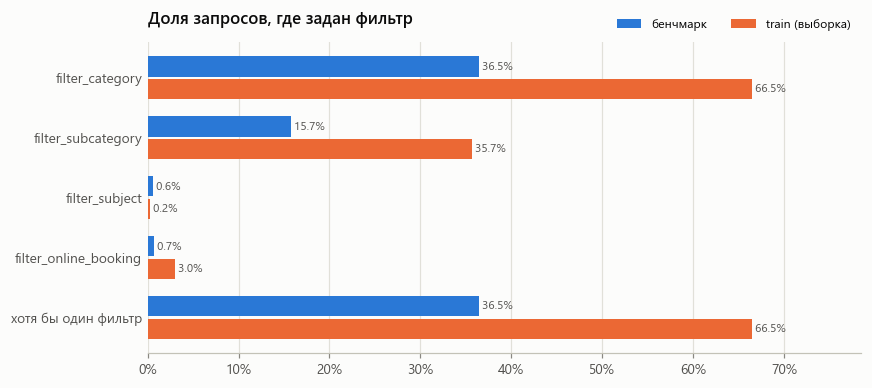

In [9]:
def is_set(series):
    """Фильтр задан: непустая строка, непустой список или True."""
    return series.map(lambda x: bool(x) if isinstance(x, (bool, np.bool_))
                      else len(ip._as_list(x)) > 0)


set_share = pd.DataFrame({
    "бенчмарк": {c: is_set(queries_p[c]).mean() for c in FILTER_COLS},
    "train (выборка)": {c: is_set(train[c]).mean() for c in FILTER_COLS},
})
set_share.loc["хотя бы один фильтр"] = [
    pd.concat([is_set(queries_p[c]) for c in FILTER_COLS], axis=1).any(axis=1).mean(),
    pd.concat([is_set(train[c]) for c in FILTER_COLS], axis=1).any(axis=1).mean(),
]

fig, ax = plt.subplots(figsize=(8, 3.6))
grouped_barh(ax, set_share.index.tolist(),
             [set_share["бенчмарк"].values, set_share["train (выборка)"].values],
             ["бенчмарк", "train (выборка)"])
ax.set_title("Доля запросов, где задан фильтр")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, set_share.values.max() * 1.18)
plt.tight_layout()
plt.show()

**Что отброшено.** Считаем запросы, у которых исходный текст фильтра был
непустым, но ни одного из четырёх фильтров не осталось, и что именно было
отброшено во всех запросах: ненужные ключи и пустые значения.

In [10]:
KEPT_KEYS = {"Вид услуги", "Тип услуги", "Предмет или специальность", "Онлайн-запись"}


def dropped_label(key, value):
    """Что отброшено из пары (ключ, значение); None — пара оставлена."""
    if key is None:
        return "непривязанный текст"
    if key not in KEPT_KEYS:
        return key
    # пустые «Вид услуги» / «Тип услуги» не отброшены: это фильтры No category / No subcategory
    if key == "Предмет или специальность" and not value:
        return f"{key}: пустое значение"
    return None


def dropped_report(df):
    had_text = df.search_infm_params_text.fillna("").str.strip() != ""
    has_kept = pd.concat([is_set(df[c]) for c in FILTER_COLS], axis=1).any(axis=1)
    labels = pd.Series([label for t in df.search_infm_params_text[had_text]
                        for k, v in ip.split_params(t)
                        if (label := dropped_label(k, v)) is not None])
    return int(had_text.sum()), int((had_text & ~has_kept).sum()), labels.value_counts()


for name, df in [("бенчмарк", queries_p), ("train (выборка)", train)]:
    n_text, n_lost, labels = dropped_report(df)
    print(f"{name}: запросов с текстом фильтра {n_text:,}, "
          f"без единого оставленного фильтра {n_lost:,} ({n_lost / n_text:.1%})")
    print(labels.head(8).to_frame("отброшено раз").to_string(), "\n")

бенчмарк: запросов с текстом фильтра 906, без единого оставленного фильтра 11 (1.2%)
                               отброшено раз
Кто оказывает услуги                      28
Рабочие дни                                7
Чем вы занимаетесь                         5
Срочная услуга (мультистатус)              3
Участие в пилоте                           3
Услуга                                     2
Преподаватель                              1
Занятия                                    1 

train (выборка): запросов с текстом фильтра 100,669, без единого оставленного фильтра 665 (0.7%)
                               отброшено раз
Тип услуги автосервиса                  8038
Кто оказывает услуги                    1910
Участие в пилоте                        1081
Срочная услуга (мультистатус)           1025
непривязанный текст                      665
Услуга                                   554
Поиск по слотам                          418
Чем вы занимаетесь                       378 



## 5. Блок A: поля объявления

`process_items` добавляет четыре поля под фильтры и текст `item_params_text`
(блок B, раздел 7).

In [11]:
ITEM_COLS = ["item_category", "item_subcategory", "item_subjects",
             "item_online_booking"]

t0 = time.time()
items_p = ip.process_items(items)
train = ip.process_items(train)
print(f"обработано за {time.time() - t0:.0f} c "
      f"({len(items_p) + len(train):,} объявлений)\n")

ip.process_items(pd.DataFrame({"item_infm_params_text": [EXAMPLE_ITEM]}))[ITEM_COLS + ["item_params_text"]].T

обработано за 53 c (339,556 объявлений)



,0
item_category,"Красота, здоровье"
item_subcategory,"СПА-услуги, массаж"
item_subjects,[]
item_online_booking,True
item_params_text,"Красота, здоровье; СПА-услуги, массаж; Спа-процедуры; Аренда бани; Баня; Спа-процедуры для тела"


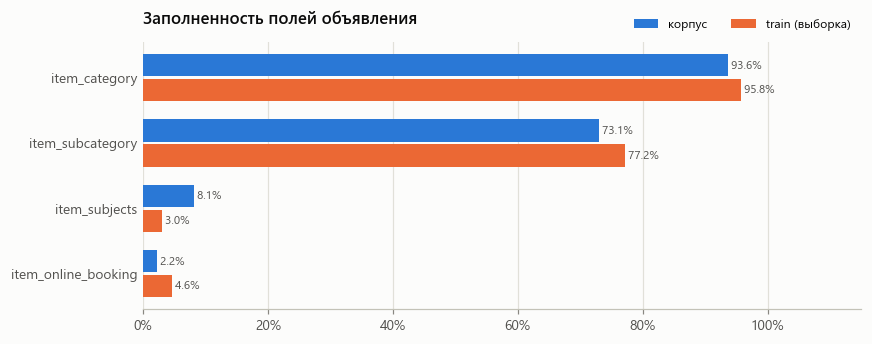

Самые частые item_subjects в корпусе: {'Другое': 2634, 'Английский язык': 1925, 'Математика': 1828, 'Русский язык': 945, 'Музыка': 929, 'Обществознание': 517}


In [12]:
def filled(df, column):
    """Доля объявлений с заполненным полем; None и метки «No …» — не заполнено."""
    if column in ("item_category", "item_subcategory"):
        return df[column].map(real_value).mean()
    return is_set(df[column]).mean()


fill = pd.DataFrame({
    "корпус": {c: filled(items_p, c) for c in ITEM_COLS},
    "train (выборка)": {c: filled(train, c) for c in ITEM_COLS},
})

fig, ax = plt.subplots(figsize=(8, 3.2))
grouped_barh(ax, fill.index.tolist(), [fill["корпус"].values, fill["train (выборка)"].values],
             ["корпус", "train (выборка)"])
ax.set_title("Заполненность полей объявления")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.show()

print("Самые частые item_subjects в корпусе:",
      pd.Series([s for x in items_p.item_subjects for s in x]).value_counts().head(6).to_dict())

### Объявления без категории

У части объявлений настоящего вида услуги нет. Таких случаев два: ключ
«Вид услуги» стоит без значения («No category») или ключа нет вовсе (`None`).
Проверим, кто это, и можно ли восстановить вид по микрокатегории.

In [13]:
no_cat = ~items_p.item_category.map(real_value)
marker = items_p.item_category == ip.NO_CATEGORY
no_key = no_cat & ~marker
with_cat_microcats = set(items_p.loc[~no_cat, "item_microcat_id"])
no_cat_microcats = set(items_p.loc[no_cat, "item_microcat_id"])

pd.DataFrame({
    "значение": [
        f"{no_cat.mean():.2%} ({no_cat.sum():,})",
        f"{marker.sum():,}, категории объявлений: "
        f"{items_p.loc[marker, 'item_category_id'].value_counts().head(3).to_dict()}",
        f"{no_key.sum():,}, категории объявлений: "
        f"{items_p.loc[no_key, 'item_category_id'].value_counts().head(4).to_dict()}",
        f"{len(no_cat_microcats):,}",
        f"{len(no_cat_microcats & with_cat_microcats)}",
    ]},
    index=[
        "объявлений корпуса без вида услуги",
        "…«No category»: ключ без значения",
        "…None: ключа нет",
        "микрокатегорий у них",
        "…из них встречаются с заполненным видом",
    ])

,значение
объявлений корпуса без вида услуги,"6.40% (12,101)"
…«No category»: ключ без значения,"10,225, категории объявлений: {114: 10225}"
…None: ключа нет,"1,876, категории объявлений: {19: 357, 112: 141, 40: 122, 33: 103}"
микрокатегорий у них,564
…из них встречаются с заполненным видом,0


«No category» — это услуги (категория 114) с незаполненным видом, а `None` —
объявления не из услуг (например, «Вид товара Стройматериалы»).

**Восстановить нельзя:** ни одна микрокатегория объявлений без вида услуги не
встречается с заполненным «Видом услуги» — пустое значение здесь свойство
целой микрокатегории.

Как с такими объявлениями обходится фильтр самого Avito? Разобьём позитивы
train по тому, какой фильтр стоял в запросе.

In [14]:
train_no_cat = ~train.item_category.map(real_value)
train_marker = train.item_category == ip.NO_CATEGORY
filter_text = train.search_infm_params_text.fillna("").str.strip()
category_filter = train.filter_category

groups = {
    "без фильтра": filter_text == "",
    "«Вид услуги» со значением": category_filter.map(real_value),
    "«Вид услуги» без значения (No category)": category_filter == ip.NO_CATEGORY,
}
pd.DataFrame({
    "пар": {g: int(m.sum()) for g, m in groups.items()},
    "объявлений без вида услуги": {g: train_no_cat[m].mean() for g, m in groups.items()},
    "…из них «No category»": {g: train_marker[m & train_no_cat].mean() for g, m in groups.items()},
}).style.format({"пар": "{:,}", "объявлений без вида услуги": "{:.2%}",
                 "…из них «No category»": "{:.1%}"})

,пар,объявлений без вида услуги,…из них «No category»
без фильтра,"49,675",5.81%,99.9%
«Вид услуги» со значением,"96,562",0.14%,97.9%
«Вид услуги» без значения (No category),"3,442",95.73%,100.0%


**Судя по данным, фильтр Avito не показывает объявления без вида услуги.**
Без фильтра таких позитивов 5.81% — почти как в корпусе (6.4%), а с
заданным видом услуги всего 0.14%. Поэтому объявление без вида услуги не
проходит фильтр с конкретным видом.

Третья строка объясняет, зачем «No category» и в запросе: если «Вид услуги»
стоит в фильтре **без значения**, 95.7% позитивов — объявления без вида
услуги, причём все они — «No category» (ключ без значения), а не `None`.
Это не отсутствие фильтра, а фильтр «ключ вида услуги без значения», и
одинаковая метка с двух сторон делает его обычным сравнением категорий.
В бенчмарке таких запросов 62 (2.5%).

Для «Тип услуги» то же самое: у позитивов фильтра без значения тип у
объявления в 94.9% случаев — ключ без значения и лишь в 1% — ключа нет.
Поэтому метка ставится только на ключ без значения, а объявления без ключа
получают `None`.

## 6. Проверка: выполняют ли позитивы фильтры — до и после

Позитивная пара «запрос → объявление» должна проходить фильтры запроса.
Сравниваем с базовой линией — тем же запросом, но **случайным** объявлением:
хороший фильтр пропускает почти все позитивы и мало случайных.

* **До:** без разбора можно проверить только, входит ли весь текст фильтра
  подстрокой в параметры объявления.
* **После:** `match_filters` проверяет каждый фильтр отдельно. Объявление
  проходит, если ни один фильтр не вернул `False`.

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(train))


def norm(s):
    return " " + re.sub(r"\s+", " ", str(s).lower()).strip() + " "


# до: весь текст фильтра — подстрока параметров
has_text = (train.search_infm_params_text.fillna("").str.strip() != "").to_numpy()
params_norm = [norm(p) for p in train.item_infm_params_text]
filters_norm = [norm(f) for f in train.search_infm_params_text.fillna("")]
before_pos = np.array([f in p for f, p in zip(filters_norm, params_norm)])[has_text]
before_rnd = np.array([filters_norm[i] in params_norm[perm[i]] for i in range(len(train))])[has_text]

# после: match_filters по каждому фильтру
F = train[FILTER_COLS].to_dict("records")
I = train[ITEM_COLS].to_dict("records")
after_pos = pd.DataFrame([ip.match_filters(f, i) for f, i in zip(F, I)])
after_rnd = pd.DataFrame([ip.match_filters(F[j], I[perm[j]]) for j in range(len(F))])

In [16]:
def pass_rate(results, cols):
    """Доля пар, где ни один фильтр из cols не вернул False, среди пар с хотя бы одним из них."""
    applicable = pd.concat([is_set(train["filter_" + c]) for c in cols], axis=1).any(axis=1)
    passed = ~results[cols].eq(False).any(axis=1)
    return passed[applicable].mean(), int(applicable.sum())


rows = [{"проверка": "до: весь текст фильтра подстрокой",
         "пар": int(has_text.sum()),
         "позитивы": before_pos.mean(), "случайные": before_rnd.mean()}]
names = {"category": "Вид услуги", "subcategory": "Тип услуги", "subject": "Предмет",
         "online_booking": "Онлайн-запись"}
for c, title in names.items():
    mask = is_set(train["filter_" + c])
    pos = ~after_pos.loc[mask, c].eq(False)
    rnd = ~after_rnd.loc[mask, c].eq(False)
    rows.append({"проверка": f"после: {title}", "пар": int(mask.sum()),
                 "позитивы": pos.mean(), "случайные": rnd.mean()})
    # отдельно — фильтры-метки «No category» / «No subcategory»
    marker = {"category": ip.NO_CATEGORY, "subcategory": ip.NO_SUBCATEGORY}.get(c)
    if marker:
        m = train["filter_" + c].map(lambda x: marker in ip._as_list(x))
        rows.append({"проверка": f"после: …из них {title} = {marker}",
                     "пар": int(m.sum()),
                     "позитивы": (~after_pos.loc[m, c].eq(False)).mean(),
                     "случайные": (~after_rnd.loc[m, c].eq(False)).mean()})

all_cols = list(names)
no_booking = [c for c in all_cols if c != "online_booking"]
for cols, title in [(all_cols, "после: все 4 фильтра"), (no_booking, "после: все, кроме онлайн-записи")]:
    p, n = pass_rate(after_pos, cols)
    r, _ = pass_rate(after_rnd, cols)
    rows.append({"проверка": title, "пар": n, "позитивы": p, "случайные": r})

check = pd.DataFrame(rows)
check.style.format({"пар": "{:,}", "позитивы": "{:.1%}", "случайные": "{:.1%}"}).hide(axis="index")

проверка,пар,позитивы,случайные
до: весь текст фильтра подстрокой,"100,669",54.0%,6.5%
после: Вид услуги,"100,004",98.3%,9.5%
после: …из них Вид услуги = No category,"3,442",95.7%,4.1%
после: Тип услуги,"53,628",98.0%,4.8%
после: …из них Тип услуги = No subcategory,"1,630",95.0%,2.9%
после: Предмет,355,98.9%,0.0%
после: Онлайн-запись,"4,569",58.4%,4.3%
после: все 4 фильтра,"100,004",95.9%,5.1%
"после: все, кроме онлайн-записи","100,004",97.8%,5.3%


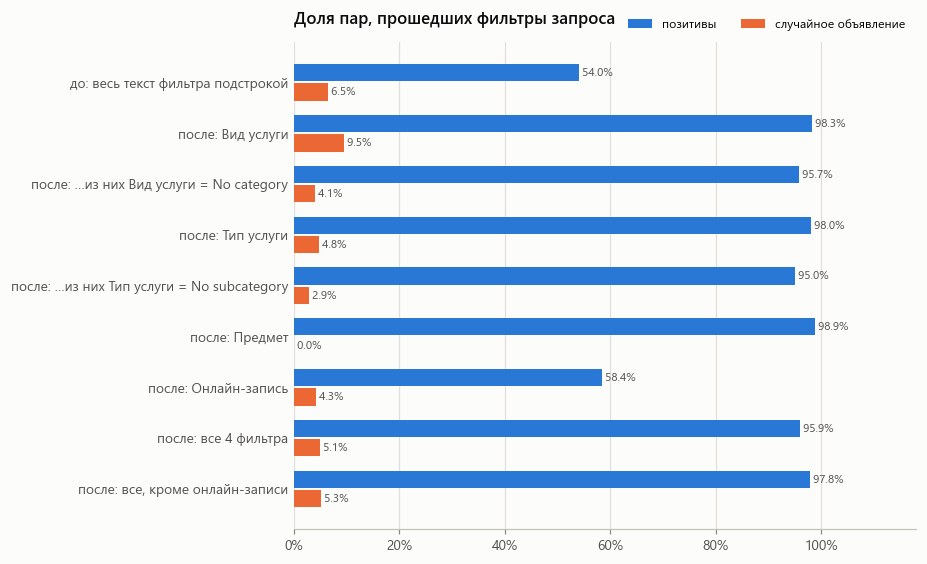

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
grouped_barh(ax, check["проверка"].tolist(),
             [check["позитивы"].values, check["случайные"].values],
             ["позитивы", "случайное объявление"])
ax.set_title("Доля пар, прошедших фильтры запроса")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, 1.18)
plt.tight_layout()
plt.show()

* **До разбора** фильтр как текст почти бесполезен: целиком подстрокой он
  входит в параметры лишь у 54.0% позитивов. Мешают другой порядок ключей и
  фильтры, которых в параметрах нет вовсе, вроде «Рейтинг пользователя».
* **После** вид, тип и предмет по отдельности выполняются у 98–99% позитивов. Вместе (без онлайн-записи) они пропускают **97.8%
  позитивов и лишь 5.3% случайных объявлений**: и позитивов остаётся почти
  вдвое больше, и лишнего отсекается больше, чем до разбора (6.5%).
* **Метки работают как полноценные фильтры:** «No category» пропускает 95.7%
  позитивов и 4.1% случайных объявлений, «No subcategory» — 95.0% и 2.9%.
* **Онлайн-запись** выполняется только у 58.4% позитивов — жёстким фильтром
  её использовать нельзя, только как признак.

### Почему пустое поле объявления — «не прошёл»

Сравним две логики для объявлений, у которых вид или тип услуги пуст:
мягкую (пропускать) и строгую (не пропускать). Смотрим, сколько позитивов
теряет строгая логика и сколько лишних объявлений пропускает мягкая. Колонки
«пусто» показывают, что доля пустых значений в корпусе и в train близка, так
что валидация на train не исказит картину.

In [18]:
def empty(value):
    """У объявления нет настоящего значения: None или метка «No …»."""
    return not real_value(value)


def rates(filter_col, item_col, strict):
    # только запросы с конкретным значением фильтра: метки «No …» разобраны выше
    mask = train[filter_col].map(lambda x: bool(ip._as_list(x))
                                 and all(real_value(v) for v in ip._as_list(x)))
    idx = np.where(mask.to_numpy())[0]
    wanted, have = train[filter_col].tolist(), train[item_col].tolist()

    def ok(f, i):
        if empty(i):
            return not strict
        values = {x.casefold() for x in ip._as_list(i)}
        return any(w.casefold() in values for w in ip._as_list(f))

    return (np.mean([ok(wanted[j], have[j]) for j in idx]),
            np.mean([ok(wanted[j], have[perm[j]]) for j in idx]))


has_cat_corpus = items_p.item_category.map(real_value)
has_cat_train = train.item_category.map(real_value)
semantics = []
for title, fcol, icol, corpus_base, train_base in [
    ("Вид услуги", "filter_category", "item_category",
     pd.Series(True, index=items_p.index), pd.Series(True, index=train.index)),
    ("Тип услуги (среди объявлений с видом)", "filter_subcategory", "item_subcategory",
     has_cat_corpus, has_cat_train),
]:
    soft_pos, soft_rnd = rates(fcol, icol, strict=False)
    strict_pos, strict_rnd = rates(fcol, icol, strict=True)
    semantics.append({
        "поле": title,
        "пусто: корпус": items_p.loc[corpus_base, icol].map(empty).mean(),
        "пусто: train": train.loc[train_base, icol].map(empty).mean(),
        "мягко: позитивы": soft_pos, "мягко: случайные": soft_rnd,
        "строго: позитивы": strict_pos, "строго: случайные": strict_rnd,
    })
pd.DataFrame(semantics).style.format(
    {c: "{:.1%}" for c in semantics[0] if c != "поле"}).hide(axis="index")

поле,пусто: корпус,пусто: train,мягко: позитивы,мягко: случайные,строго: позитивы,строго: случайные
Вид услуги,6.4%,4.2%,98.5%,13.9%,98.4%,9.7%
Тип услуги (среди объявлений с видом),22.0%,19.4%,98.6%,27.6%,98.1%,4.9%


Строгая логика почти ничего не стоит: по виду услуги она теряет 0.1 п.п.
позитивов (98.5% → 98.4%), по типу — 0.5 п.п. (98.6% → 98.1%). Мягкая же
пропускает заметно больше лишнего: 13.9% против 9.7% случайных объявлений по
виду и **27.6% против 4.9%** по типу. Доля пустых значений в корпусе и train
близка (6.4% и 4.2% для вида, 22.0% и 19.4% для типа), так что вывод
переносится на корпус.

## 7. Блок B: текст для ретрива — до и после

`item_params_text` оставляет значения категорий и содержательных полей
(названия услуг из прайс-листа, специальность, предметы, марки, производители)
и выкидывает цены, расписание, адрес, флаги, служебные поля и заглушки вроде
«Своя услуга» / «Другое».

In [19]:
print("ДО (item_infm_params_text):\n")
print(EXAMPLE_ITEM)
print("\nПОСЛЕ (item_params_text):\n")
print(ip.parse_item_params(EXAMPLE_ITEM)["item_params_text"])

ДО (item_infm_params_text):

Вид услуги Красота, здоровье Место оказания услуг Санкт-Петербург, садоводческое некоммерческое товарищество Веретено-2, Цветочная ул., 146 Тип услуги СПА-услуги, массаж Тип стоимости за час Где вы оказываете услуги У себя дома Ваши клиенты Женщины Ваши клиенты Мужчины Кто оказывает услуги Женщина Кто оказывает услуги Мужчина Специальность или сфера Спа-процедуры Начальная цена Тип стоимости за час Услуга Аренда бани Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час Услуга Баня Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час Услуга Спа-процедуры для тела Стоимость 1600 Продолжительность 1 ч Онлайн-запись Провайдер Календарей бронирования avito Признак предзаполнения прайс листа 2 Опыт работы Больше 10 лет Куда выезжаете Не выезжаю

ПОСЛЕ (item_params_text):

Красота, здоровье; СПА-услуги, массаж; Спа-процедуры; Аренда бани; Баня; Спа-процедуры для тела


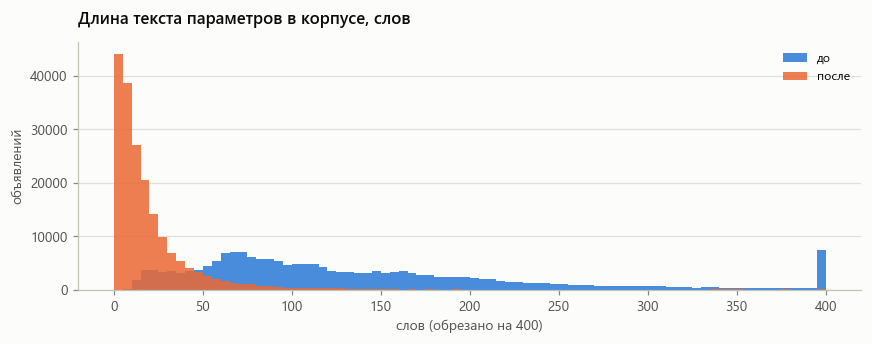

,mean,50%,90%,max
до,143.8,110.0,272.0,2468.0
после,19.9,11.0,44.0,1746.0


In [20]:
len_before = items_p.item_infm_params_text.str.split().str.len()
len_after = items_p.item_params_text.map(lambda s: len(s.split()))

fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.linspace(0, 400, 81)
ax.hist(np.clip(len_before, 0, 400), bins=bins, color=SERIES[0], alpha=0.85, label="до")
ax.hist(np.clip(len_after, 0, 400), bins=bins, color=SERIES[1], alpha=0.85, label="после")
ax.set_title("Длина текста параметров в корпусе, слов")
ax.set_xlabel("слов (обрезано на 400)")
ax.set_ylabel("объявлений")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"до": len_before.describe(percentiles=[.5, .9]),
              "после": len_after.describe(percentiles=[.5, .9])}).T[["mean", "50%", "90%", "max"]].round(1)

**Сохраняется ли сигнал.** Берём позитивные пары, где у запроса **нет ни
одного общего слова** с заголовком и описанием объявления, — их лексический
поиск по основному тексту не найдёт. Смотрим, в какой доле из них общие слова
появляются, если добавить параметры: целиком или только `item_params_text`.

In [21]:
TOKEN = re.compile(r"\w+")
tok = lambda s: set(TOKEN.findall(str(s).lower()))

q = train.search_query.map(tok).tolist()
main = [tok(a) | tok(b) for a, b in zip(train.item_title_raw, train.item_description_raw)]
zero = [i for i in range(len(train)) if q[i] and not (q[i] & main[i])]

raw_params = [tok(train.item_infm_params_text.iat[i]) for i in zero]
clean_params = [tok(train.item_params_text.iat[i]) for i in zero]
rescued_raw = np.mean([bool(q[i] & p) for i, p in zip(zero, raw_params)])
rescued_clean = np.mean([bool(q[i] & p) for i, p in zip(zero, clean_params)])

signal = pd.DataFrame({
    "средняя длина, слов": [train.item_infm_params_text.str.split().str.len().mean(),
                            train.item_params_text.map(lambda s: len(s.split())).mean()],
    "находит пары без общих слов": [rescued_raw, rescued_clean],
}, index=["до: item_infm_params_text", "после: item_params_text"])

print(f"пар без общих слов с заголовком и описанием: {len(zero):,} "
      f"({len(zero) / len(train):.1%} выборки)")
print(f"сохранено сигнала: {rescued_clean / rescued_raw:.0%} при тексте в "
      f"{signal.iloc[0, 0] / signal.iloc[1, 0]:.1f} раза короче")
signal.style.format({"средняя длина, слов": "{:.0f}", "находит пары без общих слов": "{:.1%}"})

пар без общих слов с заголовком и описанием: 15,913 (10.6% выборки)
сохранено сигнала: 89% при тексте в 6.6 раза короче


,"средняя длина, слов",находит пары без общих слов
до: item_infm_params_text,170,34.4%
после: item_params_text,26,30.5%


Текст стал в 6.6 раза короче (26 слов вместо 170 в среднем на выборке
train; медиана по корпусу — 11 вместо 110), а находит 30.5% пар без общих
слов против 34.4% у полного текста. **Сохраняется 89% лексического
сигнала**. Выброшенные ~85% слов — это цены, расписание, адрес и названия
полей.

**Длинный хвост.** У части объявлений `item_params_text` остаётся очень
длинным. Посмотрим, что там.

In [22]:
long_mask = len_after > 300
print(f"объявлений с item_params_text длиннее 300 слов: {long_mask.sum():,} "
      f"({long_mask.mean():.2%} корпуса)\n")

longest = items_p.loc[len_after.idxmax(), "item_infm_params_text"]
longest_pairs = ip.split_params(longest)
print(f"самое длинное: {len_after.max():,} слов, пар «ключ — значение»: {len(longest_pairs)}")
print("частые ключи:", pd.Series([k for k, _ in longest_pairs]).value_counts().head(5).to_dict(), "\n")
print("пример значения «Название услуги»:")
print(next(v for k, v in longest_pairs if k == "Название услуги" and len(v.split()) > 25))

объявлений с item_params_text длиннее 300 слов: 711 (0.38% корпуса)

самое длинное: 1,746 слов, пар «ключ — значение»: 269
частые ключи: {'Тип стоимости': 51, 'Начальная цена': 51, 'Название услуги': 50, 'Стоимость': 50, 'Услуга': 50} 

пример значения «Название услуги»:
Помощь в установке приложений недоступных в России помощь с приложениями другого региона на айфоне установить иностранное приложение на айфон помощь помогите установить приложение не из российского AppStore помощь с доступом к зарубежным приложениям iPhone


Это не ошибка разбора, а **SEO-спам**: продавец набил «Название услуги»
поисковыми фразами. Объявлений с текстом длиннее 300 слов — 711 (0.38%
корпуса). В индексе они будут «ловить» слишком много запросов, поэтому при
построении ретрива длину `item_params_text` стоит ограничить.

## 8. Итоги

In [23]:
summary = pd.DataFrame([
    ("Непривязанных слов после разбора (корпус)",
     f"{coverage['параметры корпуса']['доля непривязанных слов']:.2%}"),
    ("Запросов бенчмарка хотя бы с одним фильтром",
     f"{set_share.loc['хотя бы один фильтр', 'бенчмарк']:.1%}"),
    ("Позитивы проходят фильтры: до → после (кроме онлайн-записи)",
     f"{check.iloc[0]['позитивы']:.1%} → {check.iloc[-1]['позитивы']:.1%}"),
    ("Случайные объявления проходят: до → после (кроме онлайн-записи)",
     f"{check.iloc[0]['случайные']:.1%} → {check.iloc[-1]['случайные']:.1%}"),
    ("Объявлений корпуса без категории", f"{no_cat.mean():.1%}"),
    ("Длина текста параметров: до → после (медиана, слов)",
     f"{len_before.median():.0f} → {len_after.median():.0f}"),
    ("Сохранено лексического сигнала блоком B", f"{rescued_clean / rescued_raw:.0%}"),
], columns=["показатель", "значение"])
summary.style.hide(axis="index")

показатель,значение
Непривязанных слов после разбора (корпус),0.17%
Запросов бенчмарка хотя бы с одним фильтром,36.5%
Позитивы проходят фильтры: до → после (кроме онлайн-записи),54.0% → 97.8%
Случайные объявления проходят: до → после (кроме онлайн-записи),6.5% → 5.3%
Объявлений корпуса без категории,6.4%
"Длина текста параметров: до → после (медиана, слов)",110 → 11
Сохранено лексического сигнала блоком B,89%


**Блок A — фильтры**

* Словарь из 172 ключей разбирает текст почти полностью: в фильтрах
  бенчмарка непривязанных слов нет, в параметрах корпуса — 0.17%.
* В бенчмарке реально работают вид услуги (36.5% запросов, включая 62
  запроса с «No category») и тип услуги (15.7%, включая 21 запрос с
  «No subcategory»); предмет и онлайн-запись
  встречаются меньше чем в 1% запросов. «Кто оказывает услуги» отброшен:
  проверяемые значения «Женщина» / «Мужчина» есть лишь в одном запросе.
* Вместе (без онлайн-записи) фильтры пропускают 97.8% позитивов и 5.3%
  случайных объявлений — против 54.0% и 6.5% до разбора.
* Пустое поле объявления считается несоответствием, как у фильтра Avito.
* Ключ «Вид услуги» / «Тип услуги» без значения с обеих сторон — метка
  «No category» / «No subcategory»; ключа нет — `None`. Фильтры-метки
  работают как обычные: 62 и 21 запрос бенчмарка. Восстановить настоящий вид
  по микрокатегории нельзя.

**Блок B — текст для ретрива**

* `item_params_text` в 6.6 раза короче исходного текста и сохраняет 89%
  лексического сигнала.

**Открытые вопросы**

1. SEO-спам в названиях услуг (0.38% корпуса) — ограничить длину текста при
   индексации.
2. Онлайн-запись — только мягкий признак.

## 9. Что дальше: остальные поля параметров

Кроме блоков A и B, в параметрах объявления есть ещё две группы полей. Решение
по ним: **блок C отложен до появления ранжирующей модели, блок D уже выполнен.**

### Блок C — признаки для ранжирования (отложен)

| Поле | Заполненность в корпусе | Что из него можно сделать |
|---|---|---|
| Опыт работы | 76.4% | годы; два формата вперемешку: числа (`10`, `5`) и диапазоны (`10 лет и больше`, `4–7 лет`, `Меньше года`) — привести к нижней границе |
| Тип стоимости | 92.6% | категория: «за услугу» у 86%, дальше «за час», «за м²», «за день» |
| Прайс-лист | 66.8% (медиана 4 позиции) | число позиций, минимальная и медианная стоимость; `item_price` совпадает с минимумом прайса только в 39% случаев, так что это отдельный сигнал |
| Флаги | 15–34% | Работа по договору (34%), Работаете с юрлицами и ИП (33%), Гарантия (26%), Готов закупить материалы (20%), Предоплата (17%), Берёте ли срочные заказы (15%) |
| Формат работы | 20–38% | «Куда выезжаете» (37.8%), «Как вы работаете» (29.1%: у себя / у клиента / удалённо), «Бригада» (20.6%) |

**Почему отложен:**

1. Это признаки второго этапа — переранжирования кандидатов. Пока нет базового
   ретрива и офлайн-валидации, их пользу нельзя измерить.
2. Главная проблема сейчас в ретриве: у 28% релевантных пар запрос не делит с
   заголовком ни одного слова (см. `01_eda.ipynb`). Это решается текстом и
   эмбеддингами, а не опытом работы или предоплатой.
3. Запросы короткие (медиана — 3 слова) и почти не упоминают цену, опыт или
   условия работы, так что влияние этих полей на релевантность не доказано.
4. Разбор не бесплатный: нужна нормализация форматов опыта и единиц цены.
5. Отложить ничего не стоит: `split_params` уже раскладывает пары по группам
   `numeric`, `flag` и `attribute`, поэтому признаки C позже извлекаются из уже
   разобранных пар без переделки.

**Проверено отдельно:** не нужен ли раньше флаг «Как вы работаете: Удалённо».
Гипотеза была такая: при фильтрации кандидатов по локации (она совпадает у
83.1% позитивов) удалённые услуги из других городов могли бы объяснять
остальные ~17%. Связь оказалась слабой: у удалённых объявлений локация не
совпадает в 22.9% случаев против 16.3% у остальных, а на удалённые приходится
лишь 11.9% всех несовпадений локации (выборка train, 149 тыс. пар). Флаг тоже
отложен.

**Когда возвращаться:** после базового ретрива, ранжирования и валидации —
добавлять признаки C по одному и проверять прирост метрики. Но и тогда они не
первые в очереди: раньше стоит попробовать уже готовые чистые колонки
(`item_rating`, `item_rating_reviews_count`, `item_price`, совпадение
`location_id`) и результаты `match_filters`.

### Блок D — выбросить (выполнено)

| Поле | Почему не нужно |
|---|---|
| Место оказания услуг (99%) | дублирует `item_location_id` и координаты |
| Расписание: график, время работы, время для связи, дни (21% текста) | для поиска услуги почти бесполезно; максимум — флаг «работает в выходные», он отложен вместе с блоком C |
| Служебные поля: признаки прайс-листа, провайдер календаря | не описывают услугу |

В `item_params_text` этих полей уже нет. Исходная колонка `item_infm_params_text`
пока остаётся в данных, так как `process_items` только добавляет колонки;
удалять ли её, решим при подключении модуля к `src/preprocess.py`.